# Sephora E-Commerce EDA: 04 - NLP & Sentiment analysis

This notebook analyzes the review text itself. We downsample the dataset to 50k rows for faster tokenization, clean strings, build Word Clouds of positive/negative reviews, and calculate sentiment scores using VADER.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import re

from src.data_loader import load_reviews
from src.viz_utils import set_custom_style

set_custom_style()

# Load reviews with text, sample 50,000 for speed
reviews_sample = load_reviews("../data", include_text=True, verbose=False).sample(50000, random_state=42)

Custom plotting style and palettes configured successfully.


## 1. Review Word Length Distribution

<string>:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


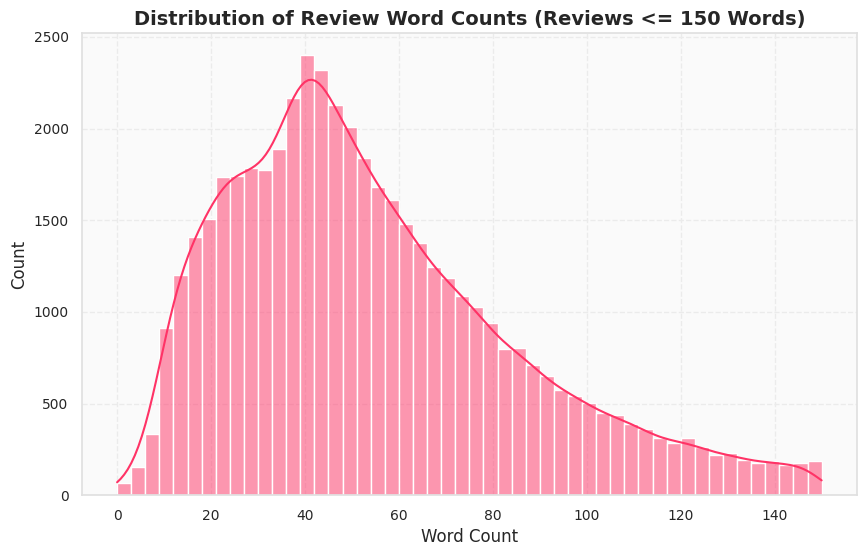

In [2]:
reviews_sample["word_count"] = reviews_sample["review_text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=reviews_sample[reviews_sample["word_count"] <= 150], x="word_count", kde=True, color="#FF3366", bins=50)
plt.title("Distribution of Review Word Counts (Reviews <= 150 Words)", fontsize=14, weight="bold")
plt.xlabel("Word Count")
plt.ylabel("Count")
plt.show()

## 2. Text Mining: Top Words in 5-Star vs 1-Star Reviews

<string>:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


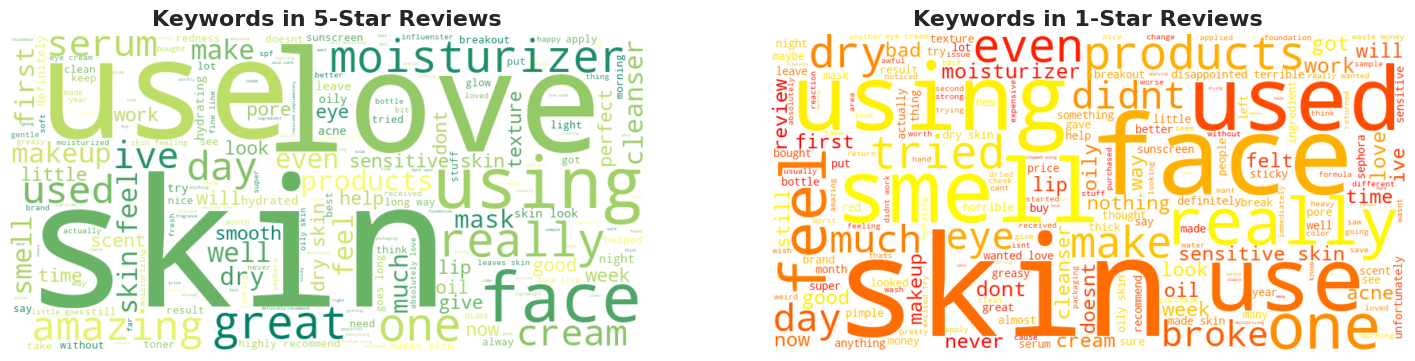

In [3]:
pos_reviews = " ".join(reviews_sample[reviews_sample["rating"] == 5]["review_text"].astype(str).tolist()[:5000])
neg_reviews = " ".join(reviews_sample[reviews_sample["rating"] == 1]["review_text"].astype(str).tolist()[:5000])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    stop_words = {"the", "and", "a", "of", "to", "is", "in", "it", "i", "this", "my", "for", "with", "but", "on", "was", "that", "so", "have", "with", "product"}
    return " ".join([w for w in text.split() if w not in stop_words and len(w) > 2])

cleaned_pos = clean_text(pos_reviews)
cleaned_neg = clean_text(neg_reviews)

# Generate Word Clouds
wc_pos = WordCloud(width=800, height=400, background_color="white", colormap="summer").generate(cleaned_pos)
wc_neg = WordCloud(width=800, height=400, background_color="white", colormap="autumn").generate(cleaned_neg)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(wc_pos, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Keywords in 5-Star Reviews", fontsize=16, weight="bold")

axes[1].imshow(wc_neg, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Keywords in 1-Star Reviews", fontsize=16, weight="bold")
plt.show()

## 3. VADER Sentiment Scoring

Let's see if VADER Sentiment Scores correlate well with review rating stars.

<string>:7: FutureWarning: 
Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
<string>:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


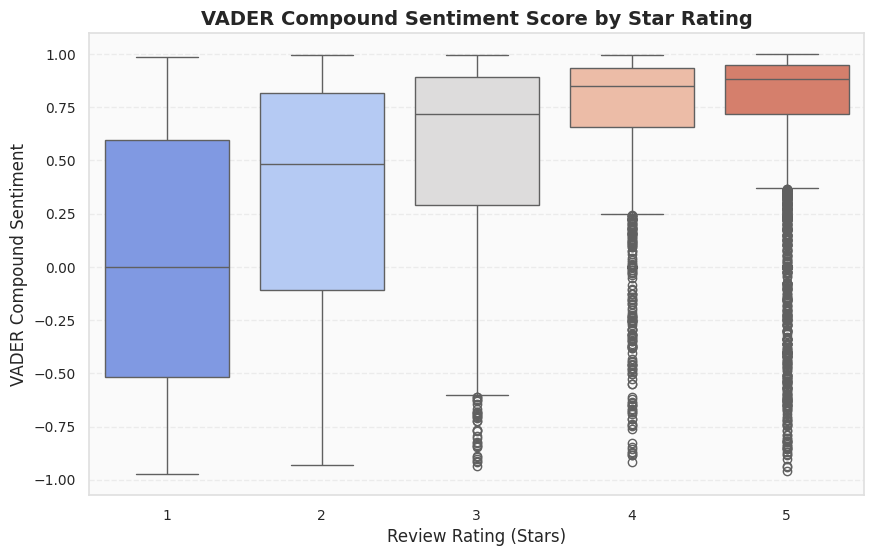

In [4]:
analyzer = SentimentIntensityAnalyzer()

sentiment_sample = reviews_sample.sample(10000, random_state=42).copy()
sentiment_sample["vader_compound"] = sentiment_sample["review_text"].apply(lambda x: analyzer.polarity_scores(str(x))["compound"])

plt.figure(figsize=(10, 6))
sns.boxplot(data=sentiment_sample, x="rating", y="vader_compound", palette="coolwarm")
plt.title("VADER Compound Sentiment Score by Star Rating", fontsize=14, weight="bold")
plt.xlabel("Review Rating (Stars)")
plt.ylabel("VADER Compound Sentiment")
plt.show()